# Decimation Pipeline Test

This notebook captures several DMA frames from the decimation pipeline, unpacks each `uint32` word into signed 16-bit I/Q samples, and plots the output spectrum.

**Assumptions**
- ADC0 is receiving a **1092 MHz** test tone.
- The RFDC/NCO is configured so that 1090 MHz is translated to baseband (for example, NCO = -1090 MHz).
- The complete decimation chain outputs **10 MSPS complex I/Q**.
- Each DMA word is packed as **[31:16] = I, [15:0] = Q**.
- The DMA stream produces TLAST correctly so each requested frame can complete.

With a 1092 MHz input and a -1090 MHz NCO, the expected output tone is approximately **+2 MHz**.

In [1]:

import xrfclk
from pynq import Overlay, allocate
import numpy as np
import time
import matplotlib.pyplot as plt
xrfclk.set_ref_clks()#lmk=122.88, lmx=409.6

FRAME_SAMPLES = 256

ol = Overlay("top_design.bit")

BITSTREAM = "top_design.bit"   # Change if required
DMA_NAME = "axi_dma_0"         # Change to the DMA name in your overlay

FS_OUT = 10e6                    # Final complex sample rate after decimation
FRAME_SAMPLES = 1024             # uint32 IQ words per DMA frame
NUM_FRAMES = 8                   # Number of frames to capture

ADC_INPUT_FREQ = 1092e6
NCO_FREQ = -1090e6
EXPECTED_BASEBAND = ADC_INPUT_FREQ + NCO_FREQ

print(f"Expected baseband tone: {EXPECTED_BASEBAND/1e6:.3f} MHz")

Expected baseband tone: 2.000 MHz


In [2]:
print("Available IP:")
for name in ol.ip_dict.keys():
    print("  ", name)

dma = getattr(ol, DMA_NAME)


print(f"\nUsing DMA: {DMA_NAME}")

Available IP:
   axi_dma_0
   rfdc
   zynq_ultra_ps_e_0

Using DMA: axi_dma_0


If the DMA is not named `axi_dma_0`, use the list printed above and change `DMA_NAME` in the configuration cell.

In [3]:
rx_buffer = allocate(shape=(FRAME_SAMPLES,), dtype=np.uint32)
captured_frames = []

for frame_idx in range(NUM_FRAMES):
    print(frame_idx)
    dma.recvchannel.transfer(rx_buffer)
    dma.recvchannel.wait()

    captured_frames.append(np.array(rx_buffer, copy=True))

    transferred = getattr(dma.recvchannel, "transferred", FRAME_SAMPLES * 4)
    print(f"Frame {frame_idx + 1}/{NUM_FRAMES}: {transferred} bytes transferred")

rx_buffer.freebuffer()

packed = np.concatenate(captured_frames)

print(f"\nTotal packed IQ samples: {len(packed):,}")
print(f"Capture duration: {len(packed)/FS_OUT*1e3:.3f} ms")

0
Frame 1/8: 1024 bytes transferred
1
Frame 2/8: 1024 bytes transferred
2
Frame 3/8: 1024 bytes transferred
3
Frame 4/8: 1024 bytes transferred
4
Frame 5/8: 1024 bytes transferred
5
Frame 6/8: 1024 bytes transferred
6
Frame 7/8: 1024 bytes transferred
7
Frame 8/8: 1024 bytes transferred

Total packed IQ samples: 8,192
Capture duration: 0.819 ms


In [4]:
q_u16 = ((packed >> 16) & 0xFFFF).astype(np.uint16)
i_u16 = (packed & 0xFFFF).astype(np.uint16)

I = i_u16.view(np.int16)
Q = q_u16.view(np.int16)

x = I.astype(np.float64) + 1j * Q.astype(np.float64)

print("First 10 packed words / unpacked samples:")
for k in range(min(10, len(packed))):
    print(f"{k:2d}: 0x{int(packed[k]):08X}  I={int(I[k]):6d}  Q={int(Q[k]):6d}")

print(f"\nI range: {I.min()} to {I.max()}")
print(f"Q range: {Q.min()} to {Q.max()}")

First 10 packed words / unpacked samples:
 0: 0x00000000  I=     0  Q=     0
 1: 0x00000000  I=     0  Q=     0
 2: 0xFFFEFFFD  I=    -3  Q=    -2
 3: 0x000A000E  I=    14  Q=    10
 4: 0xFFCFFFB9  I=   -71  Q=   -49
 5: 0xFED9FFC4  I=   -60  Q=  -295
 6: 0xFF730114  I=   276  Q=  -141
 7: 0x00D500DB  I=   219  Q=   213
 8: 0x0111FF78  I=  -136  Q=   273
 9: 0xFFD2FED3  I=  -301  Q=   -46

I range: -308 to 307
Q range: -307 to 307


In [5]:
N = len(x)
window = np.hanning(N)

X = np.fft.fftshift(np.fft.fft(x * window)) / np.sum(window)
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/FS_OUT))

mag_dbfs = 20 * np.log10(np.maximum(np.abs(X) / 32768.0, 1e-15))

peak_idx = np.argmax(mag_dbfs)
peak_freq = f[peak_idx]
peak_level = mag_dbfs[peak_idx]

print(f"FFT size: {N:,}")
print(f"Frequency resolution: {FS_OUT/N:.1f} Hz")
print(f"Peak frequency: {peak_freq/1e6:.6f} MHz")
print(f"Peak level: {peak_level:.2f} dBFS")
print(f"Expected frequency: {EXPECTED_BASEBAND/1e6:.6f} MHz")

FFT size: 8,192
Frequency resolution: 1220.7 Hz
Peak frequency: 1.993408 MHz
Peak level: -53.32 dBFS
Expected frequency: 2.000000 MHz


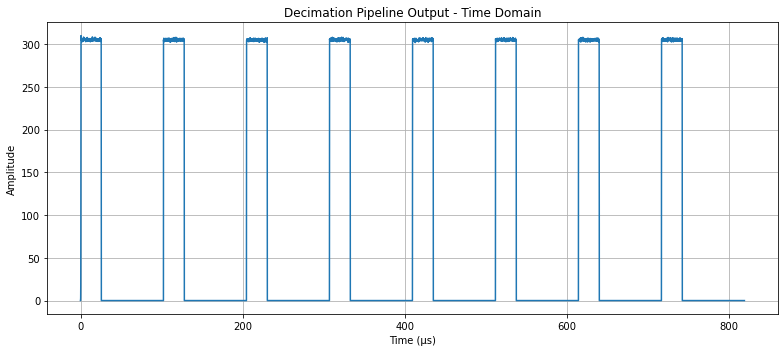

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


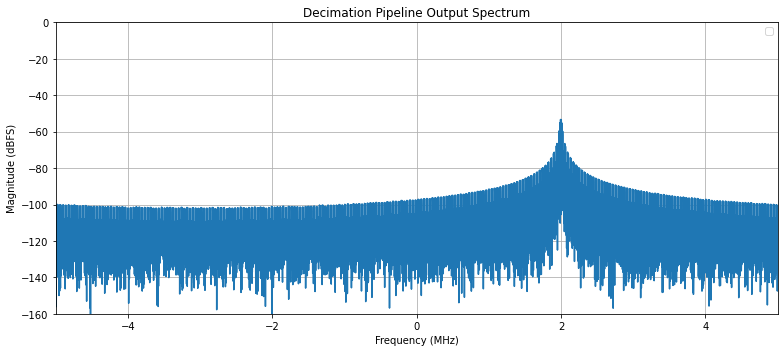

In [6]:
#Time domain
# ============================================================
t_out = np.arange(N) /FS_OUT
plt.figure(figsize=(11, 5))

plt.plot(
    t_out * 1e6,
    np.abs(x)
)

plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.title("Decimation Pipeline Output - Time Domain")
plt.grid(True)

plt.tight_layout()
plt.show()

#Frequency domain
plt.figure(figsize=(11, 5))
plt.plot(f / 1e6, mag_dbfs)
#plt.axvline(EXPECTED_BASEBAND / 1e6, linestyle="--", label="Expected +2 MHz")
plt.grid(True)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dBFS)")
plt.title("Decimation Pipeline Output Spectrum")
plt.ylim(-160, 0)
plt.xlim(-FS_OUT / 2e6, FS_OUT / 2e6)
plt.legend()
plt.tight_layout()
plt.show()